<a href="https://colab.research.google.com/github/khan65/ANGULAR-CRUD-SERVER/blob/main/Face_Recognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Cell 1: Install required libraries
!pip install face_recognition opencv-python-headless pillow numpy -q

In [ ]:
# Cell 2: ফেইস রেজিস্ট্রেশন
# একাধিক মানুষ রেজিস্ট্রি করতে বারবার রান করুন

import numpy as np
import io
import face_recognition
from PIL import Image as PILImage
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode

# রেজিস্ট্রেশন লিস্ট তৈরি (প্রথমবার)
try:
    known_face_encodings
except NameError:
    known_face_encodings = []
    known_face_names = []

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript("""
async function takePhoto(quality) {
    const div = document.createElement('div');
    div.style.cssText = 'padding:10px;background:#f0f0f0;border-radius:10px;margin:10px 0;';
    const video = document.createElement('video');
    video.style.cssText = 'display:block;width:480px;height:360px;border-radius:8px;margin:10px 0;';
    div.appendChild(video);
    const capture = document.createElement('button');
    capture.textContent = 'ছবি তুলুন';
    capture.style.cssText = 'background:#4CAF50;color:white;border:none;padding:12px 28px;font-size:16px;cursor:pointer;border-radius:8px;';
    div.appendChild(capture);
    document.querySelector("#output-area").appendChild(div);
    const stream = await navigator.mediaDevices.getUserMedia({video: true});
    video.srcObject = stream;
    await video.play();
    google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
    await new Promise((resolve) => capture.onclick = resolve);
    const canvas = document.createElement('canvas');
    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;
    canvas.getContext('2d').drawImage(video, 0, 0);
    stream.getVideoTracks()[0].stop();
    div.remove();
    return canvas.toDataURL('image/jpeg', quality);
}
""")
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# নাম ইনপুট
name = input("নাম লিখুন: ").strip()

if not name:
    print("নাম দেওয়া হয়নি! আবার রান করুন।")
else:
    print(f"'{name}' এর জন্য ছবি তোলা হচ্ছে...")
    print("ক্যামেরা খুলবে - ছবি তুলুন বাটনে ক্লিক করুন")
    filename = take_photo(f'{name}_face.jpg')
    image = face_recognition.load_image_file(filename)
    encodings = face_recognition.face_encodings(image)
    if len(encodings) == 0:
        print("কোনো মুখ পাওয়া যায়নি! আবার রান করুন।")
    else:
        known_face_encodings.append(encodings[0])
        known_face_names.append(name)
        img = PILImage.open(filename)
        display(img.resize((280, 210)))
        print(f"'{name}' সফলভাবে রেজিস্ট্রি হয়েছে!")
        print(f"রেজিস্ট্রি তালিকা: {', '.join(known_face_names)}")
        print("আরো কেউ থাকলে এই সেল আবার রান করুন।")
        print("রেজিস্ট্রেশন শেষ হলে Cell 3 রান করুন।")

নাম লিখুন: Anamul
'Anamul' এর জন্য ছবি তোলা হচ্ছে...
ক্যামেরা খুলবে - ছবি তুলুন বাটনে ক্লিক করুন


<IPython.core.display.Javascript object>

MessageError: NotAllowedError: Permission denied

রেজিস্ট্রি করা মানুষ: এনামুল, এনামুল, anamul, saad, saad
ক্যামেরা চালু হচ্ছে... ক্যামেরার দিকে তাকান!


<IPython.core.display.Javascript object>

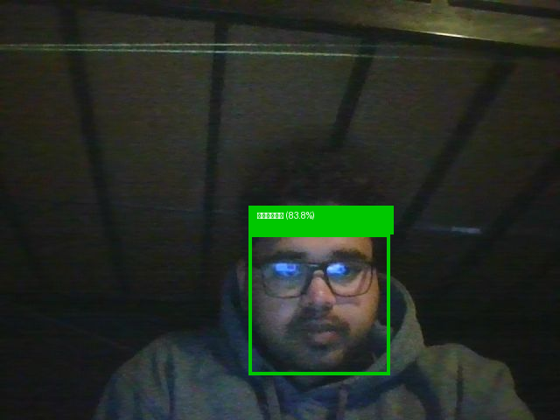

ফলাফল:
মুখ 1: এনামুল  |  নিশ্চিততা: 83.8%
মোট 1 টি মুখ ডিটেক্ট হয়েছে।
আবার চেক করতে এই সেল আবার রান করুন।


In [ ]:
# Cell 3: লাইভ ক্যামেরা - ফেইস রিকগনিশন
# ক্যামেরার সামনে দাঁড়ান, নাম দেখাবে

import face_recognition
import numpy as np
from PIL import Image as PILImage, ImageDraw
from IPython.display import display

if len(known_face_names) == 0:
    print("কেউ রেজিস্ট্রি করা নেই! আগে Cell 2 রান করুন।")
else:
    print(f"রেজিস্ট্রি করা মানুষ: {', '.join(known_face_names)}")
    print("ক্যামেরা চালু হচ্ছে... ক্যামেরার দিকে তাকান!")
    filename = take_photo('live_capture.jpg')
    test_image = face_recognition.load_image_file(filename)
    pil_image = PILImage.fromarray(test_image)
    face_locations = face_recognition.face_locations(test_image)
    face_encodings_list = face_recognition.face_encodings(test_image, face_locations)
    draw = ImageDraw.Draw(pil_image)
    results = []
    for (top, right, bottom, left), face_enc in zip(face_locations, face_encodings_list):
        matches = face_recognition.compare_faces(known_face_encodings, face_enc, tolerance=0.55)
        face_distances = face_recognition.face_distance(known_face_encodings, face_enc)
        name = "অপরিচিত"
        confidence = 0
        if len(face_distances) > 0 and True in matches:
            best_idx = np.argmin(face_distances)
            if matches[best_idx]:
                name = known_face_names[best_idx]
                confidence = round((1 - face_distances[best_idx]) * 100, 1)
        results.append((name, confidence))
        color = (0, 200, 0) if name != "অপরিচিত" else (220, 50, 50)
        draw.rectangle([left-3, top-3, right+3, bottom+3], outline=color, width=4)
        label = f" {name} ({confidence}%)" if confidence > 0 else f" {name}"
        label_w = len(label) * 11
        draw.rectangle([left-3, top-35, left-3+label_w, top-3], fill=color)
        draw.text((left+5, top-30), label, fill=(255, 255, 255))
    display(pil_image.resize((560, 420)))
    print("ফলাফল:")
    print("=" * 40)
    for i, (n, conf) in enumerate(results):
        if conf > 0:
            print(f"মুখ {i+1}: {n}  |  নিশ্চিততা: {conf}%")
        else:
            print(f"মুখ {i+1}: {n}")
    if not results:
        print("কোনো মুখ পাওয়া যায়নি। আবার চেষ্টা করুন।")
    print(f"মোট {len(results)} টি মুখ ডিটেক্ট হয়েছে।")
    print("আবার চেক করতে এই সেল আবার রান করুন।")